# Bagian 1 - Setup & Load

In [ ]:
!pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "smart_home_energy_consumption_large.csv"
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mexwell/smart-home-energy-consumption",
    file_path,
)
print("Kolom:", df.columns.tolist())
df.head()

/tmp/ipykernel_3577/3477495624.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 4.60M/4.60M [00:00<00:00, 5.93MB/s]


Kolom: ['Home ID', 'Appliance Type', 'Energy Consumption (kWh)', 'Time', 'Date', 'Outdoor Temperature (°C)', 'Season', 'Household Size']


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
0,94,Fridge,0.20,21:12,2023-12-02,-1.0,Fall,2
1,435,Oven,0.23,20:11,2023-08-06,31.1,Summer,5
2,466,Dishwasher,0.32,06:39,2023-11-21,21.3,Fall,3
3,496,Heater,3.92,21:56,2023-01-21,-4.2,Winter,1
4,137,Microwave,0.44,04:31,2023-08-26,34.5,Summer,5


# Bagian 2 - Pemahaman Data Awal

In [ ]:
print("Ukuran data :", df.shape)
print("\nTipe data & non-null:")
df.info()

print("\nJumlah rumah unik :", df['Home ID'].nunique())
print("Jenis peralatan   :", df['Appliance Type'].unique())
print("\nRingkasan numerik:")
df.describe()

Ukuran data : (100000, 8)

Tipe data & non-null:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Home ID                   100000 non-null  int64  
 1   Appliance Type            100000 non-null  object 
 2   Energy Consumption (kWh)  100000 non-null  float64
 3   Time                      100000 non-null  object 
 4   Date                      100000 non-null  object 
 5   Outdoor Temperature (°C)  100000 non-null  float64
 6   Season                    100000 non-null  object 
 7   Household Size            100000 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 6.1+ MB

Jumlah rumah unik : 500
Jenis peralatan   : ['Fridge' 'Oven' 'Dishwasher' 'Heater' 'Microwave' 'Air Conditioning'
 'Computer' 'TV' 'Washing Machine' 'Lights']

Ringkasan numerik:


,Home ID,Energy Consumption (kWh),Outdoor Temperature (°C),Household Size
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,250.374980,1.499952,14.950135,3.001770
std,144.435367,1.181176,14.438755,1.417077
min,1.000000,0.100000,-10.000000,1.000000
25%,125.000000,0.590000,2.400000,2.000000
50%,250.000000,1.230000,14.900000,3.000000
75%,375.000000,1.870000,27.400000,4.000000
max,500.000000,5.000000,40.000000,5.000000


# Bagian 3 - Data Cleaning

In [ ]:
# 3a. Missing value
print("Missing value per kolom:")
print(df.isna().sum())

# 3b. Duplikat baris
dup = df.duplicated().sum()
print("\nJumlah baris duplikat:", dup)
df = df.drop_duplicates()

# 3c. Konversi tipe waktu
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Hour'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour

# 3d. Validitas rentang (buang nilai janggal kalau ada)
df = df[df['Energy Consumption (kWh)'] >= 0]              # konsumsi tak boleh negatif
df = df[df['Household Size'] >= 1]                        # penghuni minimal 1

print("\nUkuran setelah cleaning:", df.shape)

Missing value per kolom:
Home ID                     0
Appliance Type              0
Energy Consumption (kWh)    0
Time                        0
Date                        0
Outdoor Temperature (°C)    0
Season                      0
Household Size              0
dtype: int64

Jumlah baris duplikat: 0


/tmp/ipykernel_3577/532294168.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour



Ukuran setelah cleaning: (100000, 9)


# Bagian 4 -  EDA (Exploratory Data Analysis)

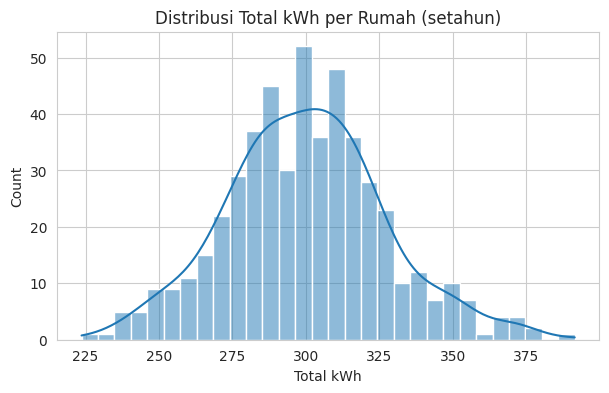

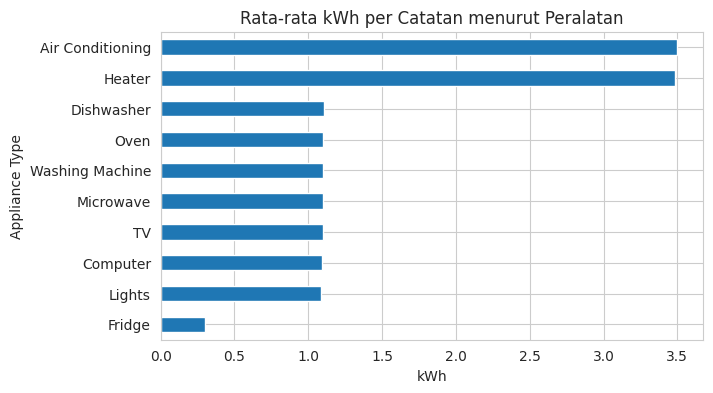

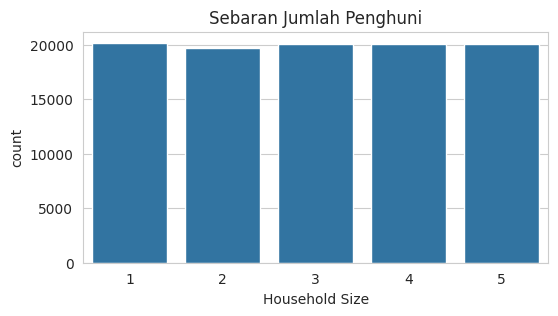

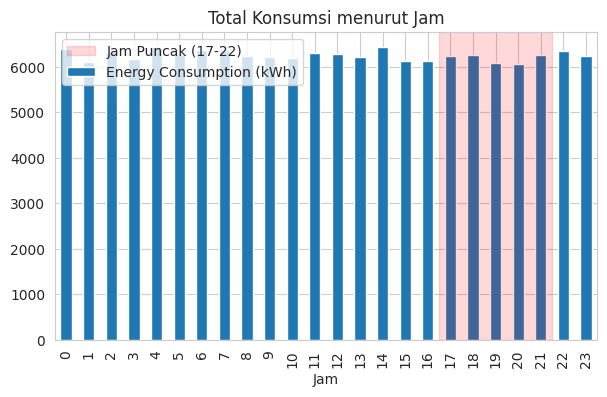

In [ ]:
sns.set_style("whitegrid")

# 4a. Total kWh per rumah (deteksi sebaran & outlier)
total_per_rumah = df.groupby('Home ID')['Energy Consumption (kWh)'].sum()
plt.figure(figsize=(7,4))
sns.histplot(total_per_rumah, bins=30, kde=True)
plt.title("Distribusi Total kWh per Rumah (setahun)")
plt.xlabel("Total kWh"); plt.show()

# 4b. Rata-rata konsumsi per jenis peralatan
plt.figure(figsize=(7,4))
df.groupby('Appliance Type')['Energy Consumption (kWh)'].mean().sort_values().plot(kind='barh')
plt.title("Rata-rata kWh per Catatan menurut Peralatan")
plt.xlabel("kWh"); plt.show()

# 4c. Distribusi jumlah penghuni
plt.figure(figsize=(6,3))
sns.countplot(x='Household Size', data=df)
plt.title("Sebaran Jumlah Penghuni"); plt.show()

# 4d. Pemakaian menurut jam (untuk konteks rekomendasi WBP)
plt.figure(figsize=(7,4))
df.groupby('Hour')['Energy Consumption (kWh)'].sum().sort_index().plot(kind='bar')
plt.axvspan(16.5, 21.5, color='red', alpha=0.15, label='Jam Puncak (17-22)')
plt.title("Total Konsumsi menurut Jam"); plt.xlabel("Jam"); plt.legend(); plt.show()

# Bagian 5 -  Feature Engineering & Agregasi (1 baris per rumah)

In [ ]:
# 5a. Agregasi dasar per rumah
agg = df.groupby('Home ID').agg(
    total_kwh_tahun=('Energy Consumption (kWh)', 'sum'),
    household_size=('Household Size', lambda x: x.mode().iloc[0]),
    avg_temp=('Outdoor Temperature (°C)', 'mean'),
).reset_index()

# 5b. kWh absolut per peralatan
pivot = (df.groupby(['Home ID', 'Appliance Type'])['Energy Consumption (kWh)']
           .sum().unstack(fill_value=0))

kwh_alat = pivot.add_prefix('kwh_')
kwh_alat.columns = [c.replace(' ', '_') for c in kwh_alat.columns]

# proporsi per peralatan (untuk clustering)
proporsi = pivot.div(pivot.sum(axis=1), axis=0).add_prefix('prop_')
proporsi.columns = [c.replace(' ', '_') for c in proporsi.columns]

# 5c. Gabung semua — TANPA kolom rupiah
df_rumah = agg.merge(kwh_alat.reset_index(), on='Home ID') \
              .merge(proporsi.reset_index(), on='Home ID')

# 5d. Fitur turunan esensial
df_rumah['kwh_per_orang'] = df_rumah['total_kwh_tahun'] / df_rumah['household_size']

print("Ukuran:", df_rumah.shape)
df_rumah.head()



Ukuran: (500, 25)


,Home ID,total_kwh_tahun,household_size,avg_temp,kwh_Air_Conditioning,kwh_Computer,kwh_Dishwasher,kwh_Fridge,kwh_Heater,kwh_Lights,...,prop_Computer,prop_Dishwasher,prop_Fridge,prop_Heater,prop_Lights,prop_Microwave,prop_Oven,prop_TV,prop_Washing_Machine,kwh_per_orang
0,1,324.76,3,13.632701,77.70,26.32,18.13,5.48,76.29,24.75,...,0.081044,0.055826,0.016874,0.234912,0.076210,0.066357,0.089297,0.048066,0.092160,108.253333
1,2,311.52,3,15.357895,56.81,26.06,14.78,5.13,80.53,27.98,...,0.083654,0.047445,0.016468,0.258507,0.089818,0.053030,0.107216,0.087699,0.073799,103.840000
2,3,332.06,5,13.097685,73.05,24.47,22.26,6.37,80.36,19.53,...,0.073692,0.067036,0.019183,0.242004,0.058815,0.118985,0.054056,0.070650,0.075589,66.412000
3,4,262.56,5,13.543333,67.30,21.09,20.37,6.67,58.37,12.02,...,0.080324,0.077582,0.025404,0.222311,0.045780,0.051226,0.054235,0.086456,0.100358,52.512000
4,5,297.07,1,13.954106,68.13,28.58,22.52,9.52,72.13,21.74,...,0.096206,0.075807,0.032046,0.242805,0.073181,0.051503,0.088935,0.052816,0.057360,297.070000


# Bagian 6 - Simpan Dataset Bersih

In [ ]:
df_rumah.to_csv('dataset_energi.csv', index=False)
print("Tersimpan:", df_rumah.shape)

from google.colab import files
files.download('dataset_energi.csv')

Tersimpan: (500, 25)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>